In [4]:
import torch                         
import torch.nn.functional as F      
import matplotlib.pyplot as plt     
%matplotlib inline                   

In [5]:
words = open('../names.txt', 'r').read().splitlines()  # read names.txt, split into a list of words (one per line)
words[:10]   

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [6]:
len(words)

32033

In [7]:
chars = sorted(list(set(''.join(words))))   # get all unique characters across all words, sorted
stoi = {s: i+1 for i, s in enumerate(chars)} # map each character to an integer (starting at 1)
stoi['.'] = 0                                # '.' is the special start/end token, mapped to index 0
itos = {i: s for s, i in stoi.items()}  

In [8]:
def build_dataset(words):
    block_size = 3          # context window: use last 3 characters to predict the next one
    X, Y = [], []           # X = inputs (context), Y = targets (next character)
    for w in words:
        context = [0] * block_size    # initialize context with block_size '.' tokens (index 0)
        for ch in w + '.':            # iterate over each char in word + trailing '.' (end token)
            ix = stoi[ch]             # look up integer index of current character
            X.append(context)         # current context window is one training input
            Y.append(ix)              # the character to predict is the label
            context = context[1:] + [ix]  # slide window: drop oldest, append current char index

    X = torch.tensor(X)   # convert list of contexts to a 2D tensor of shape (N, 3)
    Y = torch.tensor(Y)   # convert list of labels to a 1D tensor of shape (N,)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)           # seed for reproducibility
random.shuffle(words)     # shuffle words randomly
n1 = int(0.8 * len(words))   # 80% cutoff index → training set
n2 = int(0.9 * len(words))   # 90% cutoff index → dev/val set boundary

Xtr, Ytr   = build_dataset(words[:n1])     # 80% training
Xdev, Ydev = build_dataset(words[n1:n2])   # 10% validation
Xte, Yte   = build_dataset(words[n2:])     # 10% test

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [9]:
C = torch.randn((27, 2))   # random 27×2 embedding table (later replaced with seeded version)

In [31]:
g = torch.Generator().manual_seed(2147483647)  # seeded RNG for reproducibility
C  = torch.randn((27, 10),  generator=g)        # embedding table: 27 characters → 2D vectors
W1 = torch.randn((30, 200), generator=g)        # hidden layer weight: input is 3 chars × 2D = 6, output is 300 neurons
b1 = torch.randn(200,      generator=g)        # bias for hidden layer (300,)
W2 = torch.randn((200, 27),generator=g)        # output layer weight: 300 hidden → 27 logits (one per character)
b2 = torch.randn(27,       generator=g)        # bias for output layer
parameters = [C, W1, b1, W2, b2]              # collect all parameters in a list

In [38]:
sum(p.nelement() for p in parameters)   # total scalar values across all parameter tensors

torch.Size([22655, 3, 10])


In [33]:
for p in parameters:
    p.requires_grad=True

In [48]:
lossi = []   # list to record loss at each step
stepi = []   # list to record step indices

for i in range(50000):                            # train for 50,000 mini-batch steps
    ix = torch.randint(0, Xtr.shape[0], (32,))   # randomly sample 32 indices → mini-batch

    # Forward pass
    emb = C[Xtr[ix]]                             # look up embeddings for the mini-batch: shape (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # flatten embeddings to (32, 6), then → hidden layer (32, 200) with tanh
    logits = h @ W2 + b2                         # output layer: (32, 27) unnormalized log-probabilities

    loss = F.cross_entropy(logits, Ytr[ix])      # compute cross-entropy loss (handles softmax internally)

    # Backward pass
    for p in parameters:
        p.grad = None          # zero out all gradients (avoids accumulation from previous step)
    loss.backward()            # compute gradients via backpropagation

    # Parameter update (SGD)
    lr = 0.01               # fixed learning rate
    for p in parameters:
        p.data += -lr * p.grad # gradient descent: move each parameter opposite to its gradient

    lossi.append(loss.log10().item())  # record scalar loss value
    stepi.append(i)            # record step number

print(loss)   # print final loss

tensor(2.0673, grad_fn=<NllLossBackward0>)


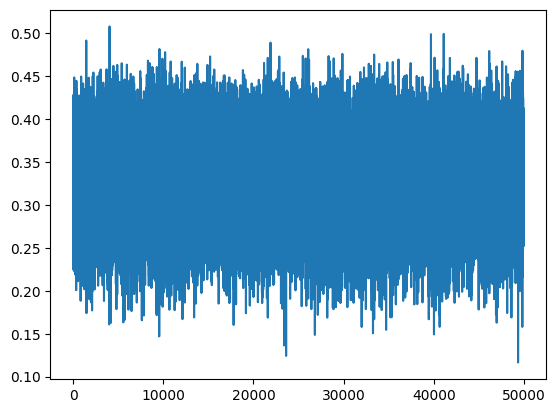

In [49]:
plt.plot(stepi, lossi)   # plot loss over training steps to visualize convergence

In [50]:
emb = C[Xdev]                              # embed the entire validation set
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # hidden layer
logits = h @ W2 + b2                       # output logits
loss = F.cross_entropy(logits, Ydev)       # validation loss
loss                                       # display it

tensor(2.1763, grad_fn=<NllLossBackward0>)

In [51]:
emb = C[Xte]                               # embed the entire test set
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # hidden layer
logits = h @ W2 + b2                       # output logits
loss = F.cross_entropy(logits, Yte)        # test loss
loss      

tensor(2.1784, grad_fn=<NllLossBackward0>)

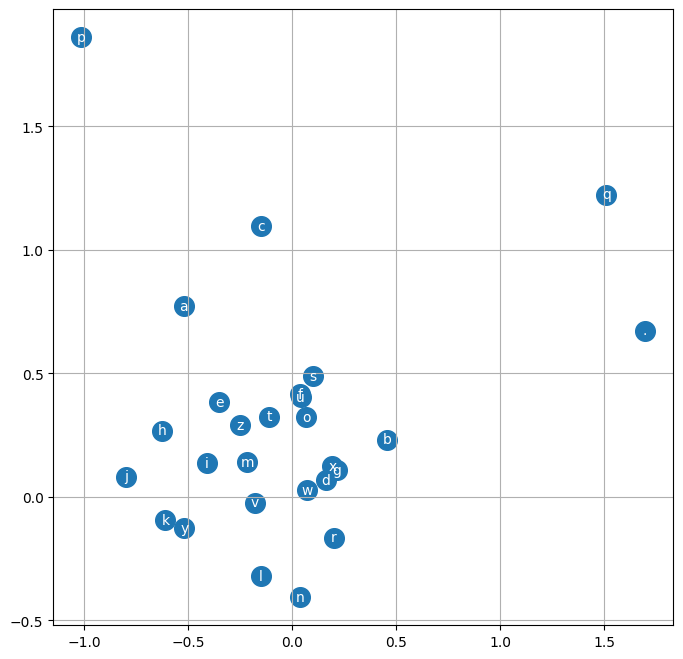

In [52]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid('minor')

In [ ]:
#result
g=torch.Generator().manual_seed(2147483647)
for i in range(20):
    out=[]
    context=[0]*block_size
    while True:
        xenc=F.one_hot(torch.tensor([ix]),num_classes=27).float() #input to the network
        logits=xenc @ W # predict log count
        count=logits.exp()
        probs=count/count.sum(1,keepdims=True)
    
        ix=torch.multinomial(probs,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(out))